# Section 0 - Config


In [ ]:
# Config

from pathlib import Path

EXPERIMENT_DIR = Path("/content/ba_pipeline")
SEED = 42

PATHS = {k: EXPERIMENT_DIR / p for k, p in {
    "data_raw": "data/raw",
    "data_processed": "data/processed",
    "models": "models",
    "shap": "shap_outputs",
    "llm": "llm_outputs",
    "results": "results",
    "subset_ids": "results/sample_subsets",
    "figures": "figures",
    "llm_runs": "llm_outputs/runs",
    "eval_runs": "results/eval_runs",
}.items()}
PATHS["root"] = EXPERIMENT_DIR

for p in PATHS.values():
    p.mkdir(parents=True, exist_ok=True)

SUBSETS = {"NAME": "subset_A_top100", "N": 100}

LLM_RUNS = [
    {"NAME": "run_001_benchmark", "MODEL": "gpt-5-mini", "N_REPEATS": 1,  "USE_CONSTRAINTS": False, "N_TX": 100},
    {"NAME": "run_002_stability", "MODEL": "gpt-5-mini", "N_REPEATS": 10, "USE_CONSTRAINTS": False, "N_TX": 10},
    {"NAME": "run_003_ablation_weaker_model", "MODEL": "gpt-5-nano", "N_REPEATS": 1, "USE_CONSTRAINTS": False, "N_TX": 100},
    {"NAME": "run_004_constraints_on", "MODEL": "gpt-5-mini", "N_REPEATS": 1, "USE_CONSTRAINTS": True, "MAX_WORDS": 200, "N_TX": 100},
    {"NAME": "run_005_negative_control_mismatched_pairing", "TYPE": "EVAL_ONLY", "SOURCE_RUN": "run_001_benchmark", "N_REPEATS": 1},
]

print(f"Root: {EXPERIMENT_DIR}\nSEED: {SEED}\nSubset: {SUBSETS['NAME']} (N={SUBSETS['N']})\nRuns:")
for r in LLM_RUNS:
    if r.get("TYPE") == "EVAL_ONLY":
        print(f" - {r['NAME']} | EVAL_ONLY | source={r['SOURCE_RUN']} | repeats={r['N_REPEATS']}")
    else:
        extra = f" | max_words={r['MAX_WORDS']}" if r.get("USE_CONSTRAINTS") else ""
        print(f" - {r['NAME']} | {r['MODEL']} | repeats={r['N_REPEATS']} | n_tx={r['N_TX']} | constraints={r['USE_CONSTRAINTS']}{extra}")

Root: /content/ba_pipeline
SEED: 42
Subset: subset_A_top100 (N=100)
Runs:
 - run_001_benchmark | gpt-5-mini | repeats=1 | n_tx=100 | constraints=False
 - run_002_stability | gpt-5-mini | repeats=10 | n_tx=10 | constraints=False
 - run_003_ablation_weaker_model | gpt-5-nano | repeats=1 | n_tx=100 | constraints=False
 - run_004_constraints_on | gpt-5-mini | repeats=1 | n_tx=100 | constraints=True | max_words=200
 - run_005_negative_control_mismatched_pairing | EVAL_ONLY | source=run_001_benchmark | repeats=1


# Section 1 - Data + Preprocessing


In [ ]:
from pathlib import Path
import json, stat
import numpy as np, pandas as pd
from google.colab import userdata

DATASET, FILENAME = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml", "HI-Small_Trans.csv"

# Kaggle auth + download
u, k = userdata.get("KAGGLE_USERNAME"), userdata.get("KAGGLE_API_TOKEN")
assert u and k, "Missing Colab secrets: KAGGLE_USERNAME / KAGGLE_API_TOKEN"
kg = Path.home() / ".kaggle"; kg.mkdir(exist_ok=True)
(kg / "kaggle.json").write_text(json.dumps({"username": u, "key": k}))
(kg / "kaggle.json").chmod(stat.S_IRUSR | stat.S_IWUSR)

%pip install -q kaggle
!kaggle datasets download -d {DATASET} -f {FILENAME} -p {str(PATHS["data_raw"])} --force

raw_path = Path(PATHS["data_raw"]) / FILENAME
df = pd.read_csv(raw_path)

# Preprocess -> train_ready.csv
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %H:%M")
df = df.reset_index(drop=True)
df["transaction_id"] = np.arange(len(df), dtype=np.int32)
df["label"] = df["Is Laundering"].astype(np.int8)
df["hour"] = df["Timestamp"].dt.hour.astype(np.int8)
df["dayofweek"] = df["Timestamp"].dt.dayofweek.astype(np.int8)
df["amount_ratio"] = df["Amount Paid"] / (df["Amount Received"] + 1e-6)
df["amount_diff"] = (df["Amount Paid"] - df["Amount Received"]).abs()

df = pd.get_dummies(df, columns=["Payment Format", "Receiving Currency", "Payment Currency"], prefix_sep="_")
df.columns = (df.columns.str.strip().str.lower()
              .str.replace(r"[^\w]+", "_", regex=True)
              .str.replace(r"_+", "_", regex=True)
              .str.strip("_"))

train_df = df.drop(columns=["timestamp", "account", "account_1", "is_laundering"], errors="ignore")
bcols = train_df.select_dtypes("bool").columns
if len(bcols): train_df[bcols] = train_df[bcols].astype(np.int8)

out_path = Path(PATHS["data_processed"]) / "train_ready.csv"
train_df.to_csv(out_path, index=False)
print(f"✅ Saved: {out_path} | shape={train_df.shape} | pos_rate={train_df['label'].mean():.4%}")

Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
License(s): Community Data License Agreement - Sharing - Version 1.0
 96% 435M/454M [00:07<00:00, 52.7MB/s]
100% 454M/454M [00:07<00:00, 64.6MB/s]
✅ Saved: /content/ba_pipeline/data/processed/train_ready.csv | shape=(5078345, 47) | pos_rate=0.1019%


# Section 2 - Model Training

In [ ]:
%pip install -q xgboost joblib

import json
import numpy as np
import pandas as pd
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# 1) Load
df = pd.read_csv(f"{PATHS['data_processed']}/train_ready.csv")

# 2) X / y (exclude identifiers)
y = df["label"].astype(np.int8)
X = df.drop(columns=["label", "transaction_id"])

# 3) Split (stratified 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# 4) Train
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0 #(class imbalance)

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)

model.fit(X_train, y_train, verbose=False)

# 5) Evaluate
proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(np.int8)
print(
    f"ROC-AUC: {roc_auc_score(y_test, proba):.4f} | "
    f"PR-AUC: {average_precision_score(y_test, proba):.4f} | "
    f"F1@0.5: {f1_score(y_test, pred):.4f}"
)

# 6) Save model + feature list
joblib.dump(model, f"{PATHS['models']}/model.pkl")
with open(f"{PATHS['models']}/features.json", "w") as f:
    json.dump(list(X.columns), f)

print("✅ Saved model + features")

ROC-AUC: 0.9685 | PR-AUC: 0.1239 | F1@0.5: 0.0326
✅ Saved model + features


## Subset sampling (helper)

In [ ]:
import json
from pathlib import Path

N = int(SUBSETS["N"])

# pool: TEST transaction_id + label + model score
pool = df.loc[X_test.index, ["transaction_id", "label"]].copy()
pool["proba"] = model.predict_proba(X_test)[:, 1]
pool = pool.sort_values(
    ["proba", "transaction_id"],
    ascending=[False, True],
    kind="mergesort",
)

A_ids = pool["transaction_id"].head(N).astype(int).to_numpy()

out_dir = Path(PATHS["subset_ids"])
out_dir.mkdir(parents=True, exist_ok=True)
(out_dir / "subset_A_ids.json").write_text(json.dumps(A_ids.tolist()))

pool_by_id = pool.set_index("transaction_id")
print(f"✅ Saved subset A: top={len(A_ids)} | pos_rate={pool_by_id.loc[A_ids, 'label'].mean():.4%}")
print(f"   proba mean={pool_by_id.loc[A_ids, 'proba'].mean():.4f}")

✅ Saved subset A: top=100 | pos_rate=43.0000%
   proba mean=0.9970


# Section 3 - SHAP

Top 15 features (mean |SHAP|):


,feature,mean_abs_shap
0,from_bank,2.348780
8,payment_format_ach,2.318723
3,amount_paid,0.981691
1,to_bank,0.674268
2,amount_received,0.561738
12,payment_format_credit_card,0.537674
4,hour,0.495158
11,payment_format_cheque,0.300315
5,dayofweek,0.295627
13,payment_format_reinvestment,0.211005


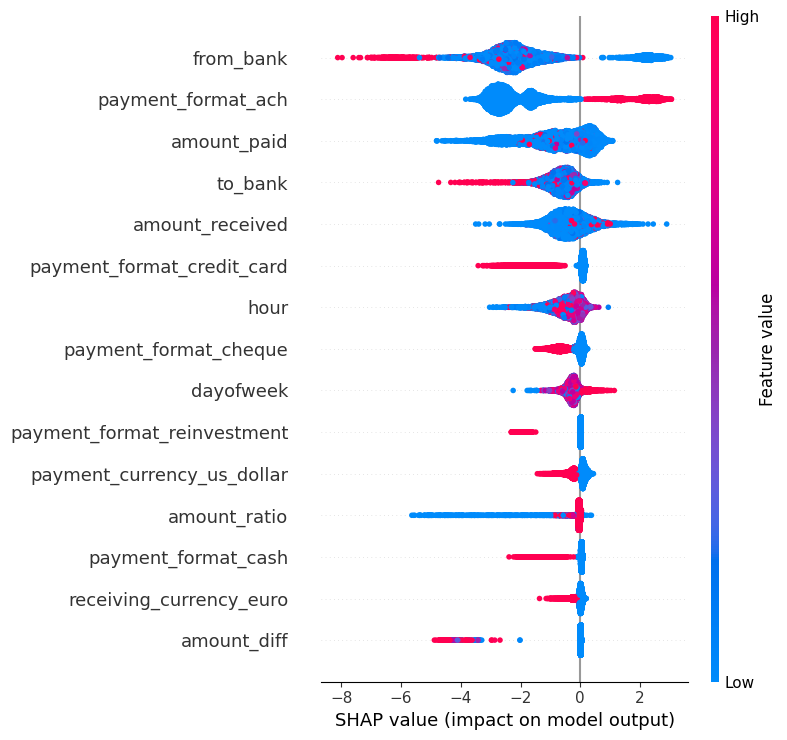

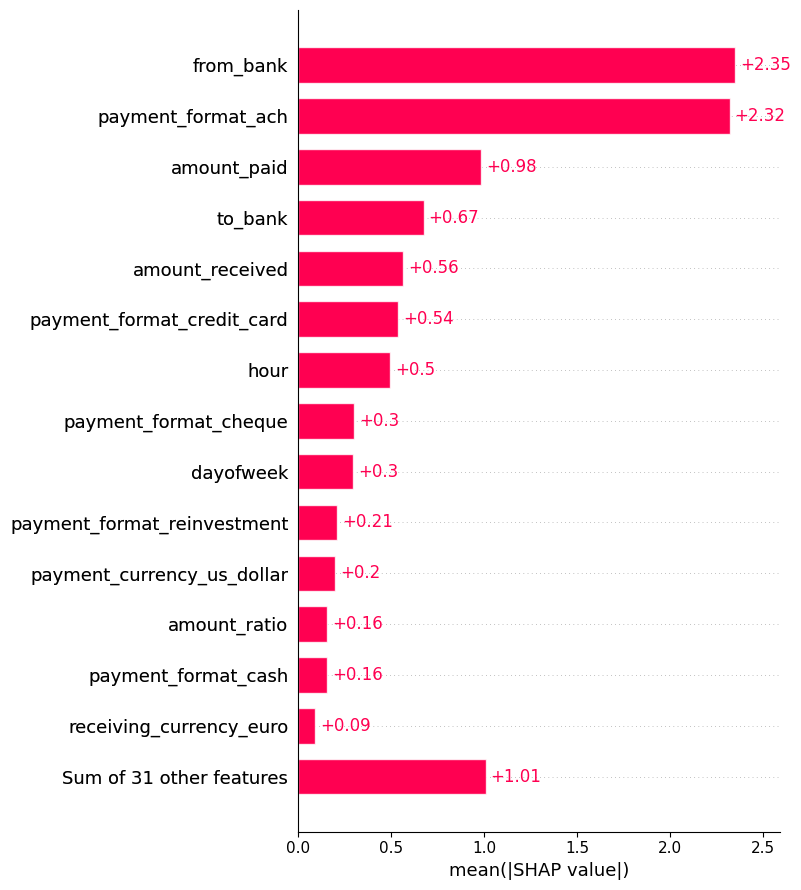

✅ Global SHAP saved: /content/ba_pipeline/shap_outputs/global


In [ ]:
# SHAP (GLOBAL) <--- not actually used in work - old artifact

%pip install -q shap

import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Sample from TEST for global SHAP
GLOBAL_SHAP_N = 10_000
X_shap = X_test.sample(n=GLOBAL_SHAP_N, random_state=SEED)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_shap)

mean_abs = np.abs(shap_values.values).mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs})
      .sort_values("mean_abs_shap", ascending=False)
)

print("Top 15 features (mean |SHAP|):")
display(importance_df.head(15))

out_dir = Path(PATHS["shap"]) / "global"
out_dir.mkdir(parents=True, exist_ok=True)

importance_df.to_csv(out_dir / "importance.csv", index=False)

with open(out_dir / "global_shap.json", "w") as f:
    json.dump(
        {
            "base_value": float(np.array(shap_values.base_values).mean()),
            "features": list(X_test.columns),
            "sample_size": int(GLOBAL_SHAP_N),
            "row_indices": X_shap.index.tolist(),
            "mean_abs_shap": mean_abs.tolist(),
        },
        f,
    )

# 5) SHAP-Plots <-- again, not used / displayed
fig_path = Path(PATHS["figures"]) / "shap_global_summary.png"
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values.values, X_shap, max_display=15, show=False)
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

bar_path = Path(PATHS["figures"]) / "shap_global_bar.png"
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

print("✅ Global SHAP saved:", out_dir)

In [ ]:
# LOCAL-SHAP: subset A -> per-tx SHAP JSON
%pip install -q shap

import json, numpy as np, shap
from pathlib import Path

TOP_N = 10
subset_dir = Path(PATHS["subset_ids"])
shap_dir = Path(PATHS["shap"]) / "local" / "A"
shap_dir.mkdir(parents=True, exist_ok=True)

A_ids = json.loads((subset_dir / "subset_A_ids.json").read_text())

# map transaction_id -> X_test index
tx_to_idx = df.loc[X_test.index].reset_index().set_index("transaction_id")["index"]
X_A = X_test.loc[tx_to_idx.loc[A_ids].to_numpy()]  # KeyError ifID missing

explainer = shap.TreeExplainer(model)
exp = explainer(X_A)
proba = model.predict_proba(X_A)[:, 1]

tx_ids = df.loc[X_A.index, "transaction_id"].astype(int).to_numpy()
feats = X_A.columns.to_list()

for i, tx_id in enumerate(tx_ids):
    vals = exp.values[i]
    top = np.argsort(-np.abs(vals))[:TOP_N]
    top_feats = [{
        "feature": feats[j],
        "value": float(X_A.iloc[i, j]),
        "shap_value": float(vals[j]),
        "direction": "increase" if vals[j] > 0 else "decrease",
    } for j in top]

    (shap_dir / f"shap_trx_{tx_id}.json").write_text(
        json.dumps(
            {"transaction_id": int(tx_id), "model_proba": float(proba[i]), "top_features": top_feats},
            indent=2,
        )
    )

In [ ]:
### TEST TOP 10 SHAP FEATURE MASS COMPARED TO ALL SHAP FEATURES

import numpy as np

# Compute SHAP values for Subset A
exp_A = explainer(X_A)
vals = exp_A.values  # shape: (n_trx, n_features)

abs_vals = np.abs(vals)
total_mass = abs_vals.sum(axis=1)

k = TOP_N  # 10 <- defined above in local shap code
# sum of top-k absolute |SHAP| per row
topk_mass = np.partition(abs_vals, -k, axis=1)[:, -k:].sum(axis=1)

ratio = topk_mass / (total_mass + 1e-12)

def pct(x):
    return 100 * float(x)

print(f"Top-{k} |SHAP| mass share on Subset A (n={len(X_A)}):")
print(f"  mean   = {pct(ratio.mean()):.2f}%")
print(f"  median = {pct(np.median(ratio)):.2f}%")
print(f"  p10–p90 = {pct(np.quantile(ratio, 0.10)):.2f}% – {pct(np.quantile(ratio, 0.90)):.2f}%")

Top-10 |SHAP| mass share on Subset A (n=100):
  mean   = 90.48%
  median = 90.92%
  p10–p90 = 87.53% – 92.63%


# Section 5 — LLM Generations

In [ ]:
#PROMPT BUILDER

import json

FACT = {
    "from_bank": "sending bank ID",
    "to_bank": "receiving bank ID",
    "amount_received": "amount received (receiving currency)",
    "amount_paid": "amount paid (payment currency)",
    "hour": "hour of day (0–23)",
    "dayofweek": "day of week (0=Mon..6=Sun)",
    "amount_ratio": "amount_paid / amount_received",
    "amount_diff": "|amount_paid − amount_received|",
    "payment_format_": "payment method indicator (1=yes, 0=no)",
    "receiving_currency_": "receiving currency indicator (1=this, 0=other)",
    "payment_currency_": "payment currency indicator (1=this, 0=other)",
}

# PROMPT:
PROMPT_NEW = """LLM System Prompt: AML Rationale Generator
Role: You are an Anti-Money Laundering (AML) analyst. Your task is to draft a structured internal rationale note for a flagged transaction.

Evidence Scope (Model Ground Truth): The following features were identified by the detection model as the primary drivers for this flag.

Drivers (SHAP):
{SHAP_EVIDENCE_JSON_OR_TEXT}

{FACTSHEET_PLACEHOLDER}

Core Requirements:

{CONSTRAINTS}
- Treat ONLY the provided drivers and transaction fields as facts.
- Do not make any specific, checkable claim unless it can be derived from the provided driver features. When referencing a driver, include the feature name.
- Reasoning: Your rationale must explicitly reference the features in the driver list to explain "Why" the transaction was flagged.
- Select only the most relevant drivers (highest absolute SHAP contributions) and omit minor drivers.


Output Structure: Answer the following points briefly:
Why: Provide the core explanation grounded in the drivers and their specific directions.
Conclusion: Brief summary assessment based solely on the above. You may add potentially helpful assumptions, but only if they are directly derived from one or more named drivers and phrased in clearly hedged/conditional language.
"""

def build_prompt(tx: dict, cfg: dict) -> str:
    constrained = bool(cfg.get("USE_CONSTRAINTS", False))  # default OFF
    top_n = int(cfg.get("TOP_N", 10))
    max_words = int(cfg.get("MAX_WORDS", 200))

    def fmt(v):
        if v is None:
            return None
        if isinstance(v, bool):
            return int(v)
        if isinstance(v, (int, float)):
            return int(v) if (isinstance(v, int) or (isinstance(v, float) and float(v).is_integer())) else float(f"{v:.6g}")
        return str(v)

    def defn(name: str):
        if name in FACT:
            return FACT[name]
        for pref in (k for k in FACT if k.endswith("_")):
            if name.startswith(pref):
                return FACT[pref]
        return None

    # Build SHAP driver evidence (JSON text)
    feats = (tx.get("top_features") or [])[:top_n]
    drivers = []
    for d in feats:
        direction = d.get("direction", "unknown")
        if direction not in ("increase", "decrease"):
            direction = "unknown"

        drivers.append({
            "feature": d.get("feature", "UNKNOWN"),
            "value": fmt(d.get("value")),
            "shap_value": fmt(d.get("shap_value")),
            "direction": direction,
        })
    shap_evidence_text = json.dumps(drivers, ensure_ascii=False, indent=2)

    seen = []
    for dr in drivers:
        name = dr["feature"]
        di = defn(name)
        if not di:
            continue

        v = dr.get("value")

        if isinstance(v, (int, float)) and name.startswith(("payment_currency_", "receiving_currency_", "payment_format_")):
            seen.append(f"- {name}: {di}; value={int(v)}")
        else:
            seen.append(f"- {name}: {di}")

    factsheet_text = "\n".join(seen).strip()
    if factsheet_text:
        factsheet_text = "Fact Sheet (feature definitions):\n" + factsheet_text

    # Constraints placeholder (toggle-able)
    constraints_text = f"- Keep the output <= {max_words} words total.\n" if constrained else ""

    return PROMPT_NEW.format(
        SHAP_EVIDENCE_JSON_OR_TEXT=shap_evidence_text,
        FACTSHEET_PLACEHOLDER=factsheet_text,
        CONSTRAINTS=constraints_text,
    ).strip()

In [ ]:
# LLM PROMPT MATERIALIZATION: build + save prompts (no API calls here yet)

import json
from pathlib import Path
from tqdm import tqdm

TOP_N = 10
STABILITY_MAX_PROMPTS = 50  # total files for stability (5 trx 10 repeats)

def build_prompts_one_cfg(run_cfg: dict):
    run_name = run_cfg["NAME"]
    repeats  = int(run_cfg.get("N_REPEATS", 1))
    n_tx     = int(run_cfg.get("N_TX", 10**9))  # optional cap per run

    shap_dir = Path(PATHS["shap"]) / "local" / "A"
    out_dir  = Path(PATHS["llm_runs"]) / run_name
    in_dir   = out_dir / "inputs"
    in_dir.mkdir(parents=True, exist_ok=True)

    # overwrite old data
    for fp in in_dir.glob("*"):
        if fp.is_file():
            fp.unlink()

    shap_files = sorted(shap_dir.glob("shap_trx_*.json"))[:n_tx]
    assert shap_files, f"No SHAP files found in {shap_dir}"

    # cap total prompts for stability - 50 standard
    total = len(shap_files) * repeats
    if "stability" in run_name.lower():
        total = min(total, STABILITY_MAX_PROMPTS)

    print(f"[{run_name}] writing {total} prompts -> {in_dir}")

    cfg_local = dict(run_cfg, TOP_N=TOP_N)

    pbar = tqdm(total=total, desc=f"{run_name} | prompts")
    written = 0
    for shap_fp in shap_files:
        tx = json.loads(shap_fp.read_text())
        tx_id = int(tx["transaction_id"])
        for r in range(1, repeats + 1):
            if written >= total:
                pbar.close()
                return
            prompt = build_prompt(tx, cfg_local)
            (in_dir / f"llm_prompt_trx_{tx_id}_r{r}.txt").write_text(prompt, encoding="utf-8")
            written += 1
            pbar.update(1)
    pbar.close()

for cfg in LLM_RUNS:
    if cfg.get("TYPE") != "EVAL_ONLY":
        build_prompts_one_cfg(cfg)

[run_001_benchmark] writing 100 prompts -> /content/ba_pipeline/llm_outputs/runs/run_001_benchmark/inputs


run_001_benchmark | prompts: 100%|██████████| 100/100 [00:00<00:00, 1739.84it/s]


[run_002_stability] writing 50 prompts -> /content/ba_pipeline/llm_outputs/runs/run_002_stability/inputs


run_002_stability | prompts: 100%|██████████| 50/50 [00:00<00:00, 1774.92it/s]


[run_003_ablation_weaker_model] writing 100 prompts -> /content/ba_pipeline/llm_outputs/runs/run_003_ablation_weaker_model/inputs


run_003_ablation_weaker_model | prompts: 100%|██████████| 100/100 [00:00<00:00, 1373.05it/s]


[run_004_constraints_on] writing 100 prompts -> /content/ba_pipeline/llm_outputs/runs/run_004_constraints_on/inputs


run_004_constraints_on | prompts: 100%|██████████| 100/100 [00:00<00:00, 1755.72it/s]


In [ ]:
import json, time, random
from pathlib import Path
from tqdm import tqdm
from google.colab import userdata
from openai import OpenAI

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
assert client.api_key, "Missing OPENAI_API_KEY in Colab secrets"

SLEEP_SUCCESS_S = 0.05
N_RETRIES = 3
BACKOFF_BASE_S = 1.0
MAX_CALLS_PER_RUN = None        # Standard: None
OVERWRITE = True

def call_llm(model: str, prompt: str) -> str:
    resp = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are an AML compliance analyst."},
            {"role": "user", "content": prompt},
        ],
    )
    return resp.choices[0].message.content.strip()

def parse_ids(fp: Path):
    stem = fp.stem
    tx_id = int(stem.split("_trx_")[1].split("_r")[0])
    r = int(stem.split("_r")[1])
    return tx_id, r

def sleep_backoff(attempt: int):
    base = BACKOFF_BASE_S * (2 ** attempt)
    time.sleep(base + random.uniform(0, BACKOFF_BASE_S))

def run_one_cfg(cfg: dict):
    run_name, model = cfg["NAME"], cfg["MODEL"]
    out_dir = Path(PATHS["llm_runs"]) / run_name
    in_dir = out_dir / "inputs"
    out_dir.mkdir(parents=True, exist_ok=True)
    assert in_dir.exists(), f"Missing prompt folder: {in_dir}"

    files = sorted(in_dir.glob("llm_prompt_trx_*_r*.txt"))
    assert files, f"No prompt files found in {in_dir}"
    if MAX_CALLS_PER_RUN is not None:
        files = files[:MAX_CALLS_PER_RUN]

    err_path = out_dir / "errors.jsonl"
    print(f"[{run_name}] n={len(files)} | overwrite={OVERWRITE}")

    for prompt_fp in tqdm(files, desc=f"{run_name} | llm"):
        tx_id, r = parse_ids(prompt_fp)
        out_fp = out_dir / f"llm_trx_{tx_id}_r{r}.json"
        if out_fp.exists() and not OVERWRITE:
            continue

        prompt = prompt_fp.read_text(encoding="utf-8")

        last_err = None
        for attempt in range(N_RETRIES):
            try:
                t0 = time.time()
                text = call_llm(model, prompt)
                latency = time.time() - t0

                out_fp.write_text(json.dumps({
                    "transaction_id": tx_id,
                    "run_name": run_name,
                    "repeat": r,
                    "model": model,
                    "latency_s": round(latency, 4),
                    "llm_text": text,
                }, indent=2, ensure_ascii=False), encoding="utf-8")

                time.sleep(SLEEP_SUCCESS_S)
                last_err = None
                break

            except Exception as e:
                last_err = str(e)
                sleep_backoff(attempt)

        if last_err:
            with err_path.open("a", encoding="utf-8") as f:
                f.write(json.dumps({
                    "transaction_id": tx_id,
                    "repeat": r,
                    "error": last_err,
                    "prompt_file": prompt_fp.name,
                }, ensure_ascii=False) + "\n")

    print(f"[{run_name}] ✅ done -> {out_dir}")

for cfg in LLM_RUNS:
    if cfg.get("TYPE") != "EVAL_ONLY":
        run_one_cfg(cfg)

[run_001_benchmark] n=100 | overwrite=True


run_001_benchmark | llm: 100%|██████████| 100/100 [29:53<00:00, 17.94s/it]


[run_001_benchmark] ✅ done -> /content/ba_pipeline/llm_outputs/runs/run_001_benchmark
[run_002_stability] n=50 | overwrite=True


run_002_stability | llm: 100%|██████████| 50/50 [15:54<00:00, 19.10s/it]


[run_002_stability] ✅ done -> /content/ba_pipeline/llm_outputs/runs/run_002_stability
[run_003_ablation_weaker_model] n=100 | overwrite=True


run_003_ablation_weaker_model | llm: 100%|██████████| 100/100 [41:02<00:00, 24.63s/it]


[run_003_ablation_weaker_model] ✅ done -> /content/ba_pipeline/llm_outputs/runs/run_003_ablation_weaker_model
[run_004_constraints_on] n=100 | overwrite=True


run_004_constraints_on | llm: 100%|██████████| 100/100 [22:12<00:00, 13.32s/it]

[run_004_constraints_on] ✅ done -> /content/ba_pipeline/llm_outputs/runs/run_004_constraints_on


# Helper - Push to Git

In [ ]:
# --- Push content

import subprocess, shutil
from pathlib import Path
from urllib.parse import quote
from google.colab import userdata

REPO_URL = "https://github.com/ZeusGav/evaluating-llm-explanations-for-aml.git"
PIPE_DIR = Path("/content/ba_pipeline")
CLONE_DIR = Path("/content/repo")

def sh(cmd, cwd=None):
    subprocess.run(cmd, cwd=cwd, check=True)

token = userdata.get("GITHUB_TOKEN")
assert token, "Missing GITHUB_TOKEN in Colab secrets"

# clone repo
if not (CLONE_DIR / ".git").exists():
    sh(["git", "clone", REPO_URL, str(CLONE_DIR)])

# git identity
sh(["git", "config", "user.email", "colab@local"], cwd=CLONE_DIR)
sh(["git", "config", "user.name", "colab"], cwd=CLONE_DIR)

# auth remote
authed = REPO_URL.replace("https://", f"https://ZeusGav:{quote(token, safe='')}@")
sh(["git", "remote", "set-url", "origin", authed], cwd=CLONE_DIR)

# merge
dst_root = CLONE_DIR / "ba_pipeline"
dst_root.mkdir(parents=True, exist_ok=True)

for p in PIPE_DIR.iterdir():
    if p.name == ".git":
        continue
    dst = dst_root / p.name
    if p.is_dir():
        shutil.copytree(p, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(p, dst)

# stage + commit + push
sh(["git", "add", "-A"], cwd=CLONE_DIR)
status = subprocess.run(["git", "status", "--porcelain"], cwd=CLONE_DIR, capture_output=True, text=True, check=True).stdout.strip()

if not status:
    print("No changes to commit.")
else:
    sh(["git", "commit", "-m", "Sync ba_pipeline"], cwd=CLONE_DIR)
    sh(["git", "push", "-u", "origin", "main"], cwd=CLONE_DIR)
    print("Pushed.")

Pushed.


# Helper - Dataset Insights

In [ ]:
# Discovery plot - not used in work - old artifact

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df_raw = pd.read_csv(raw_path)

ts = pd.to_datetime(df_raw["Timestamp"], format="%Y/%m/%d %H:%M", errors="coerce")
y = df_raw["Is Laundering"].astype(int)

n = len(df_raw)
n_pos = int(y.sum())
print(f"rows={n:,} | laundering={n_pos:,} | pos_rate={n_pos/n:.6%}")

daily = (
    pd.DataFrame({"day": ts.dt.floor("D"), "y": y})
    .groupby("day")
    .agg(n=("y","size"), pos=("y","sum"))
)
daily["pos_rate"] = daily["pos"] / daily["n"]
print(f"date_range={daily.index.min().date()}..{daily.index.max().date()} | days={len(daily):,}")

rows=5,078,345 | laundering=5,177 | pos_rate=0.101943%
date_range=2022-09-01..2022-09-18 | days=18
